# Rapport d'Analyse de données pour la stratégie marketing

C'est une analyse de données pour concevoir une stratégie marketing basée sur divers aspects tels que l'analyse de zone, l'analyse des clients, l'analyse de la catégorie de produits et les séries de temps de vente et de profit.

Objectifs :
* Analyse de zone pour identifier les marchés clés.
* Analyse client pour déterminer les clients de grande valeur.
* Analyse de la catégorie de produits pour identifier les produits les plus performants.
* Analyser les tendances de vente et de profit au fil du temps.
* Application du principe de Pareto pour prioriser les principaux moteurs des ventes et des bénéfices.

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact, Dropdown, IntSlider
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

In [56]:
data = pd.read_excel("/content/US Superstore data.xls")
data

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


Analyse Exploratoire des Données (EDA)

In [57]:
print("Dataset Shape:", data.shape)
print("\nColumn Names:")
print(data.columns.tolist())

Dataset Shape: (9994, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [58]:
data.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [59]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

Préparation et Nettoyage des Données

In [60]:
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


In [61]:
data.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [62]:
data['Profit Margin'] = (data['Profit'] / data['Sales'])*100
data['Order Year'] = data['Order Date'].dt.year
data['Order Month'] = data['Order Date'].dt.month
data['Order Month-Year'] = data['Order Date'].dt.to_period('M')

print("New features created:")
print(data[['Sales', 'Profit', 'Profit Margin', 'Order Year', 'Order Month']].head())

New features created:
      Sales    Profit  Profit Margin  Order Year  Order Month
0  261.9600   41.9136          16.00        2016           11
1  731.9400  219.5820          30.00        2016           11
2   14.6200    6.8714          47.00        2016            6
3  957.5775 -383.0310         -40.00        2015           10
4   22.3680    2.5164          11.25        2015           10


Analyse des meilleurs ventes

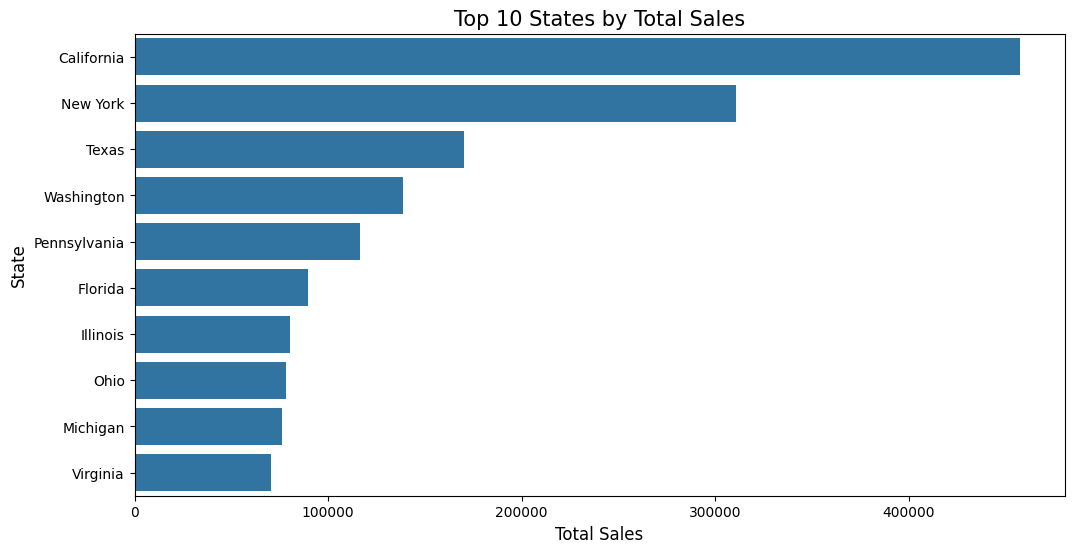

In [63]:
state_sales = data.groupby('State')['Sales'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=state_sales.head(10), x='Sales', y='State')
plt.title('Top 10 States by Total Sales', fontsize=15)
plt.xlabel('Total Sales', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.show()

les Etats qui ont le plus de ventes sont : California, New York, Texa

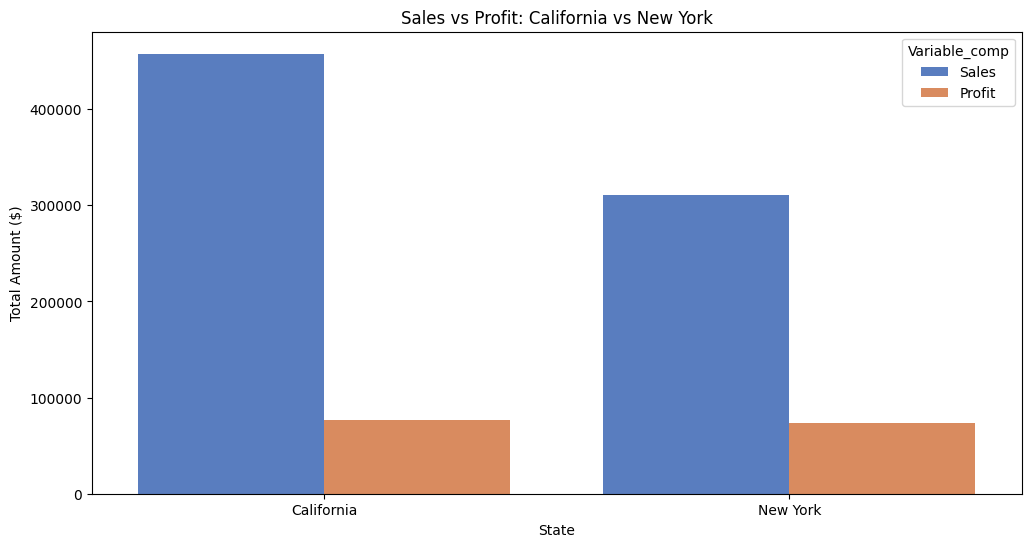

In [64]:
df1 = data[data['State'].isin(['California', 'New York'])]


df2 = df1.groupby('State')[['Sales', 'Profit']].sum().reset_index()


df = df2.melt(id_vars='State', var_name='Variable_comp', value_name='Amount')

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='State', y='Amount', hue='Variable_comp', palette='muted')
plt.title('Sales vs Profit: California vs New York')
plt.ylabel('Total Amount ($)')
plt.show()


la california vends plus , mais l'Etat de New York est aussi rentable que l'Etat de Calfornia.

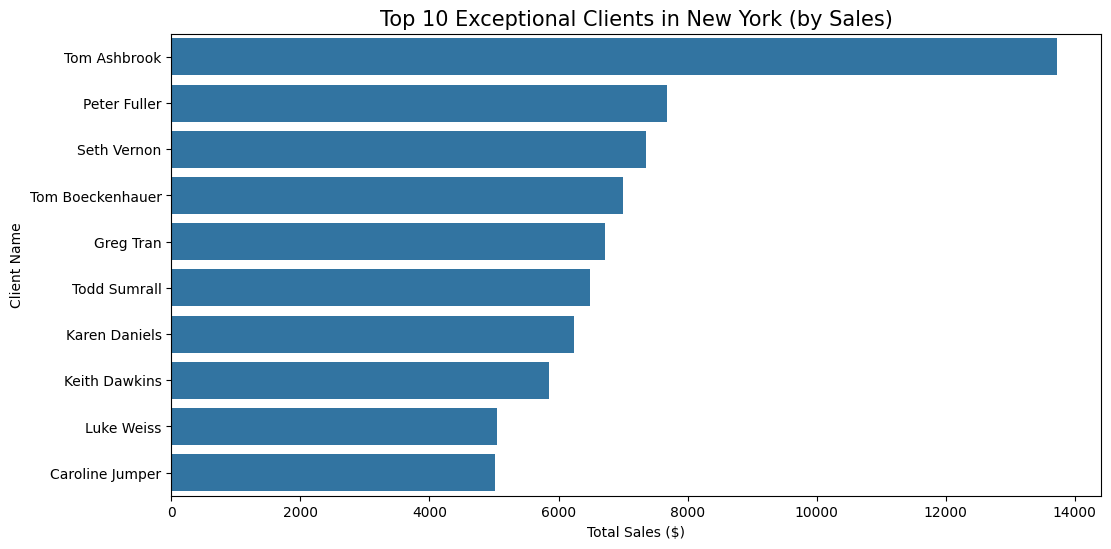



The most exceptional customer (VIP) in New York is Tom Ashbrook with a total of 13,723.50 $ for sales.


In [65]:
df1= data[data['State'] == 'New York']

df = df1.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=df.head(10), x='Sales', y='Customer Name')
plt.title('Top 10 Exceptional Clients in New York (by Sales)', fontsize=15)
plt.xlabel('Total Sales ($)')
plt.ylabel('Client Name')
plt.show()

top_customer = df.iloc[0]
print(f"\n\nThe most exceptional customer (VIP) in New York is {top_customer['Customer Name']} with a total of {top_customer['Sales']:,.2f} $ for sales.")

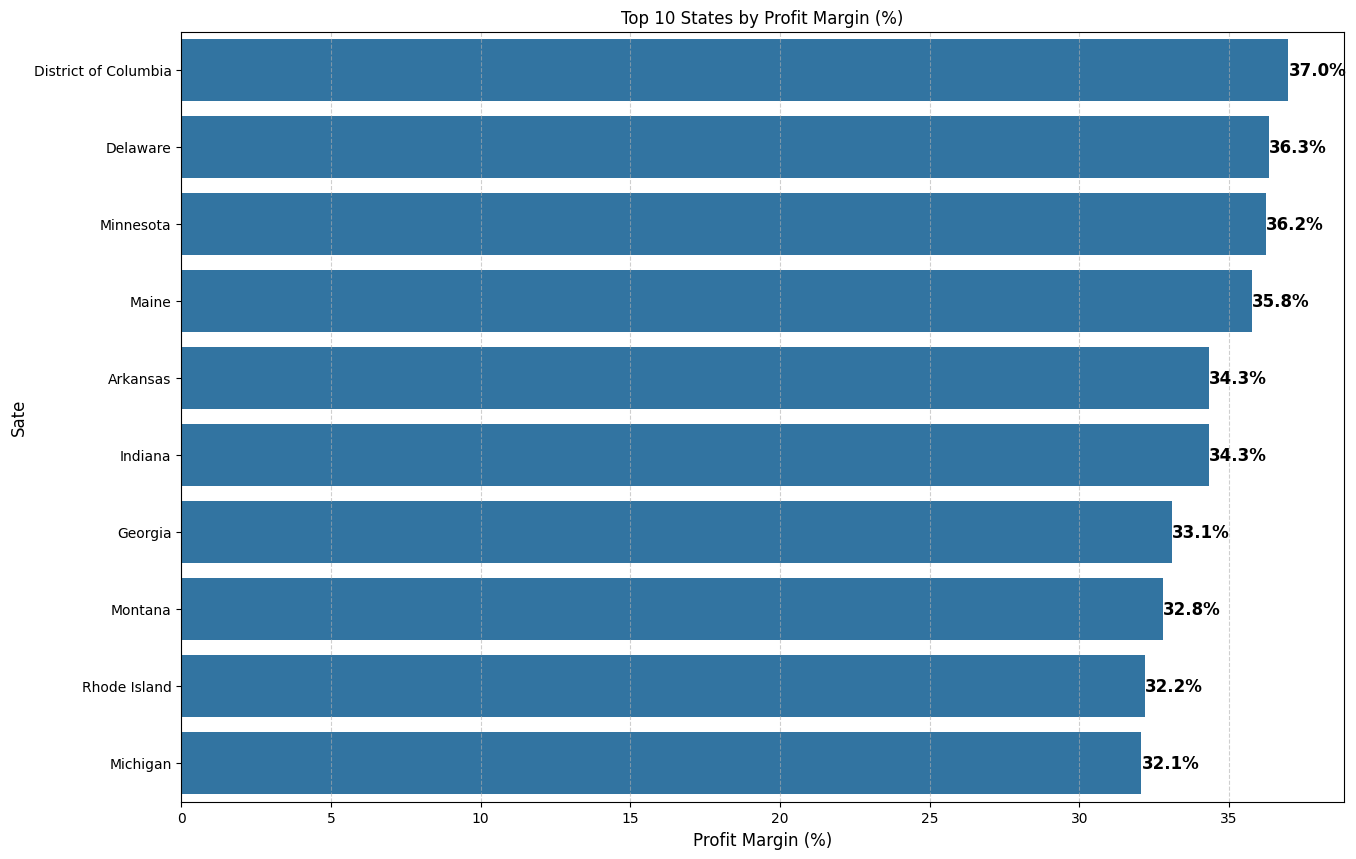



Top 10 Most Profitable States (by profit margin):
               State  Profit Margin %
District of Columbia        36.983662
            Delaware        36.346034
           Minnesota        36.242618
               Maine        35.771387
            Arkansas        34.326447
             Indiana        34.325110
             Georgia        33.098615
             Montana        32.800377
        Rhode Island        32.197470
            Michigan        32.074618


In [72]:
df = data.groupby('State').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()
df['Profit Margin %'] = (df['Profit'] / df['Sales']) * 100


df = df.sort_values(by='Profit Margin %', ascending=False)


plt.figure(figsize=(15, 10))
sns.barplot(data=df.head(10), x='Profit Margin %', y='State')


for index, value in enumerate(df.head(10)['Profit Margin %']):
    plt.text(value, index, f'{value:.1f}%', va='center', fontsize=12, fontweight='bold')

plt.title('Top 10 States by Profit Margin (%)', fontsize=12)
plt.xlabel('Profit Margin (%)', fontsize=12)
plt.ylabel('Sate', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()


print("\n\nTop 10 Most Profitable States (by profit margin):")
print(df[['State', 'Profit Margin %']].head(10).to_string(index=False))

Commantaires : Les Etats qui font les plus grand nombre de ventes n'ont pas de grande marge beneficiaire (profit margin)

Seul l'Etat du Michigan fait exception.

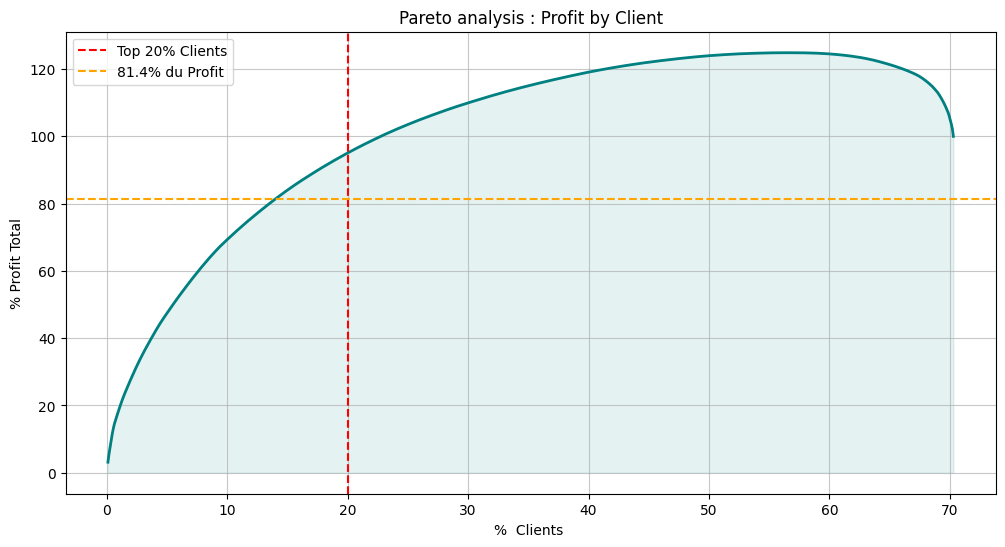



Resultats of analysis:
- Number of customers representing 20% of the customer base:  158
- Percentage of total profit generated by these customers: 81.43%


In [79]:
df = data.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False).reset_index()

df['Cumulative_Profit'] = df['Profit'].cumsum()
df['Profit_Percentage'] = 100 * df['Cumulative_Profit'] / df['Profit'].sum()
df['Customer_Rank_Pct'] = 100 * (df.index + 1) / len(df1)


nb = int(len(df) * 0.2)
top_20_data = df.iloc[nb - 1]
profit_from_20 = top_20_data['Profit_Percentage']


plt.figure(figsize=(12, 6))
plt.plot(df['Customer_Rank_Pct'], df['Profit_Percentage'], color='teal', linewidth=2)
plt.fill_between(df['Customer_Rank_Pct'], df['Profit_Percentage'], color='teal', alpha=0.1)

plt.axvline(20, color='red', linestyle='--', label='Top 20% Clients')
plt.axhline(profit_from_20, color='orange', linestyle='--', label=f'{profit_from_20:.1f}% du Profit')

plt.title('Pareto analysis : Profit by Client', fontsize=12)
plt.xlabel('%  Clients ')
plt.ylabel('% Profit Total')
plt.legend()
plt.grid(True, alpha=0.7)
plt.show()

print(f"\n\nResultats of analysis:")
print(f"- Number of customers representing 20% of the customer base:  {nb}")
print(f"- Percentage of total profit generated by these customers: {profit_from_20:.2f}%")

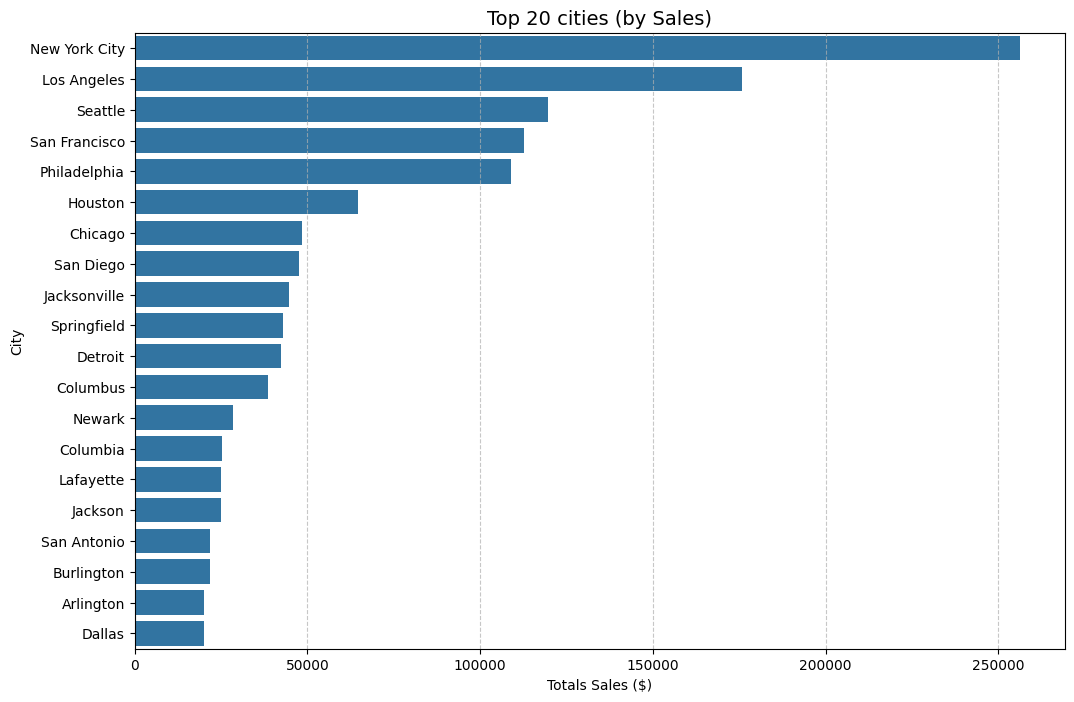



Top 20 Cities by Sales :
         City       Sales
New York City 256368.1610
  Los Angeles 175851.3410
      Seattle 119540.7420
San Francisco 112669.0920
 Philadelphia 109077.0130
      Houston  64504.7604
      Chicago  48539.5410
    San Diego  47521.0290
 Jacksonville  44713.1830
  Springfield  43054.3420
      Detroit  42446.9440
     Columbus  38706.2430
       Newark  28576.1190
     Columbia  25283.3240
    Lafayette  25036.2000
      Jackson  24963.8580
  San Antonio  21843.5280
   Burlington  21668.0820
    Arlington  20214.5320
       Dallas  20131.9322


In [77]:
city_sales = data.groupby('City')['Sales'].sum().reset_index()

top_20_cities = city_sales.sort_values(by='Sales', ascending=False).head(20)


plt.figure(figsize=(12, 8))
sns.barplot(data=top_20_cities, x='Sales', y='City')
plt.title('Top 20 cities (by Sales)', fontsize=14)
plt.xlabel('Totals Sales ($)')
plt.ylabel('City')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


print("\n\nTop 20 Cities by Sales :")
print(top_20_cities.to_string(index=False))

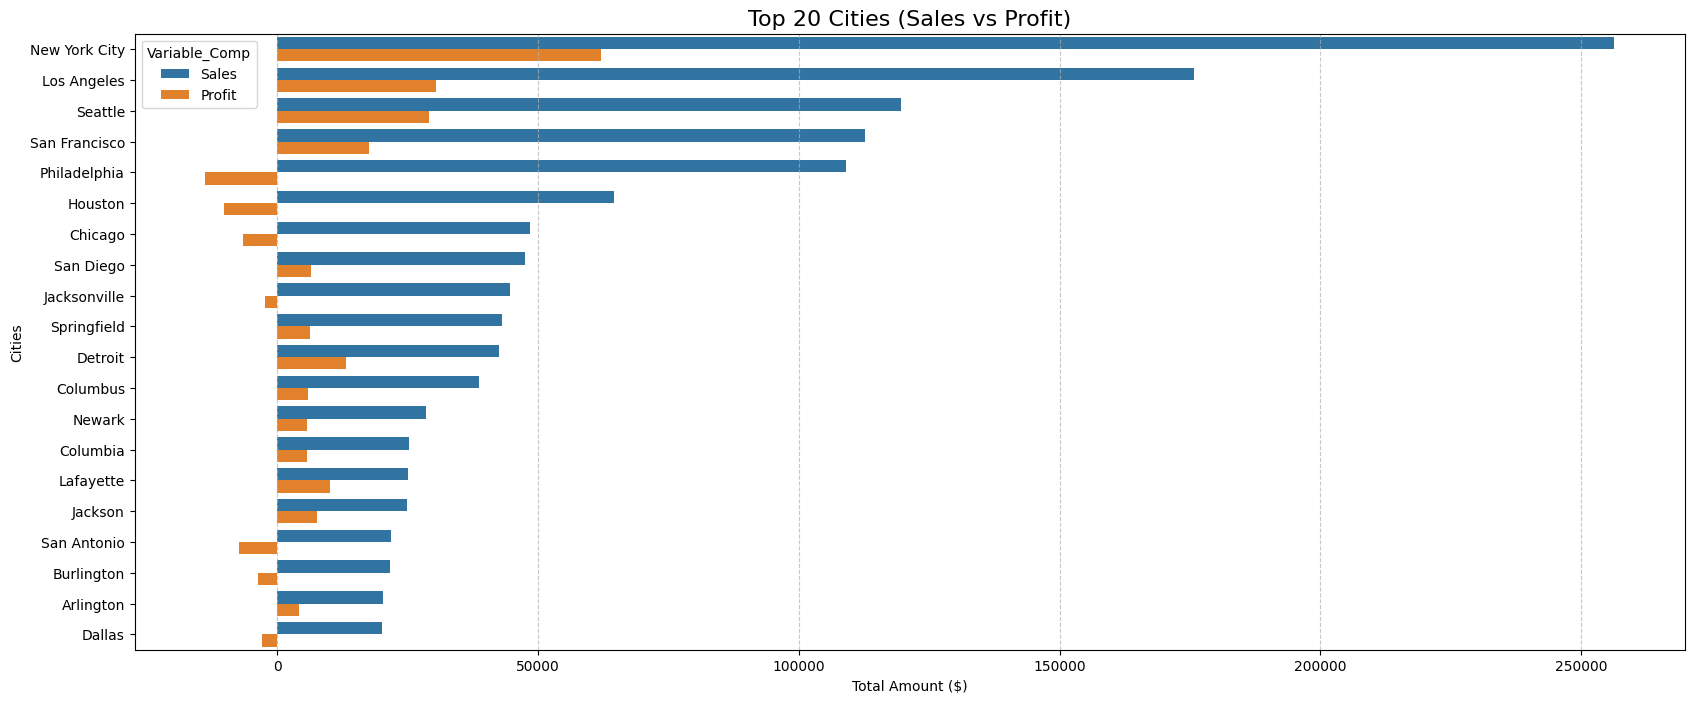

Rentability Analisis (Top 20 by Sales) :
             City        Sales      Profit  Profit_Margin
14      Lafayette   25036.2000  10018.3876      40.015608
10        Detroit   42446.9440  13181.7908      31.054746
15        Jackson   24963.8580   7581.6828      30.370637
2         Seattle  119540.7420  29156.0967      24.390092
0   New York City  256368.1610  62036.9837      24.198396
13       Columbia   25283.3240   5606.1167      22.173179
18      Arlington   20214.5320   4169.6969      20.627225
12         Newark   28576.1190   5793.7588      20.274827
1     Los Angeles  175851.3410  30440.7579      17.310507
3   San Francisco  112669.0920  17507.3854      15.538765
11       Columbus   38706.2430   5897.1013      15.235530
9     Springfield   43054.3420   6200.6974      14.402026
7       San Diego   47521.0290   6377.1960      13.419735
8    Jacksonville   44713.1830  -2323.8350      -5.197203
4    Philadelphia  109077.0130 -13837.7674     -12.686236
6         Chicago   48539.5410 

In [84]:
city_data= data.groupby('City').agg({'Sales': 'sum', 'Profit': 'sum'}).sort_values(by='Sales', ascending=False).head(20).reset_index()


city_data['Profit_Margin'] = (city_data['Profit'] / city_data['Sales']) * 100


city_S_P = city_data.melt(id_vars='City', value_vars=['Sales', 'Profit'], var_name='Variable_Comp', value_name='Amount')


plt.figure(figsize=(20, 8))
sns.barplot(data=city_S_P, x='Amount', y='City', hue='Variable_Comp')
plt.title('Top 20 Cities (Sales vs Profit)', fontsize=16)
plt.xlabel('Total Amount ($)')
plt.ylabel('Cities')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Affichage des villes avec les marges les plus faibles/élevées
print("Rentability Analisis (Top 20 by Sales) :")
print(city_data[['City', 'Sales', 'Profit', 'Profit_Margin']].sort_values(by='Profit_Margin', ascending=False))

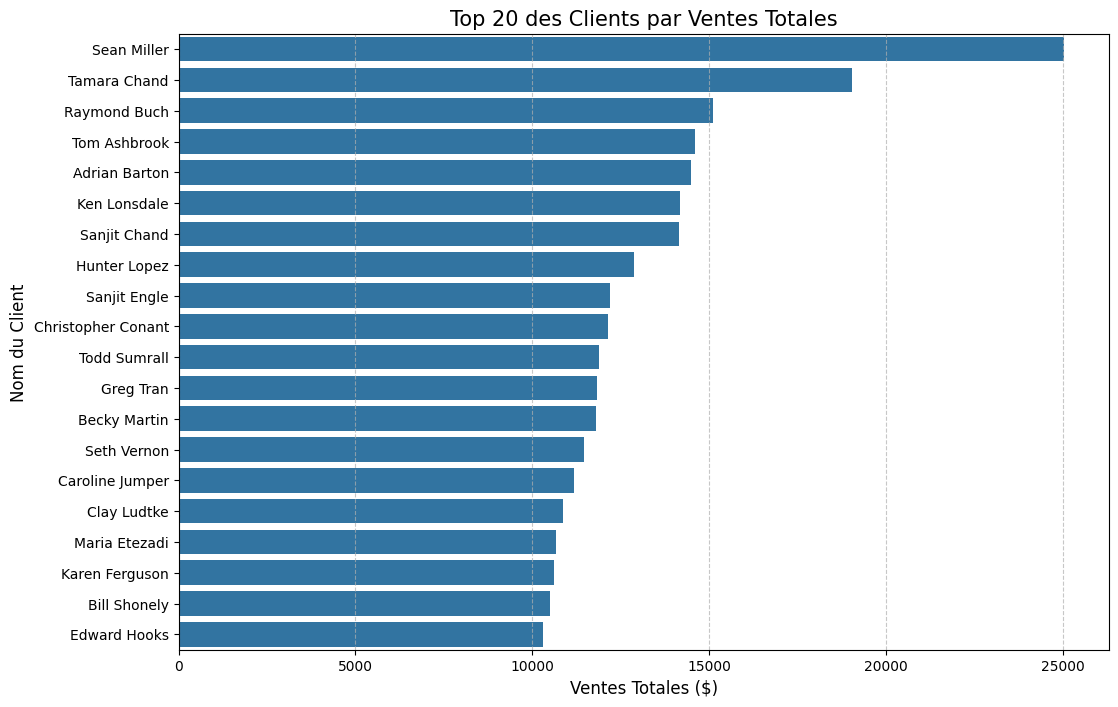

Top 20 clients VIP :
         Customer Name      Sales
0          Sean Miller  25043.050
1         Tamara Chand  19052.218
2         Raymond Buch  15117.339
3         Tom Ashbrook  14595.620
4        Adrian Barton  14473.571
5         Ken Lonsdale  14175.229
6         Sanjit Chand  14142.334
7         Hunter Lopez  12873.298
8         Sanjit Engle  12209.438
9   Christopher Conant  12129.072
10        Todd Sumrall  11891.751
11           Greg Tran  11820.120
12        Becky Martin  11789.630
13         Seth Vernon  11470.950
14     Caroline Jumper  11164.974
15         Clay Ludtke  10880.546
16       Maria Etezadi  10663.728
17      Karen Ferguson  10604.266
18        Bill Shonely  10501.653
19        Edward Hooks  10310.880


In [83]:
top_20_customers = data.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(20).reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(data=top_20_customers, x='Sales', y='Customer Name')
plt.title('Top 20 des Clients par Ventes Totales', fontsize=15)
plt.xlabel('Ventes Totales ($)', fontsize=12)
plt.ylabel('Nom du Client', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Top 20 clients VIP :")
print(top_20_customers)

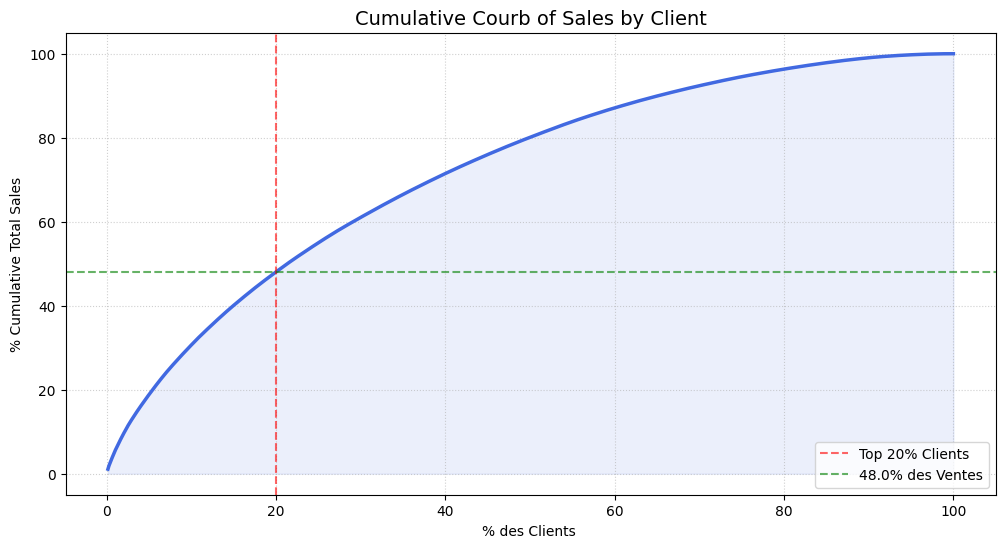



 Analisis , Top 20% of clients represent 47.96% of total Sales.


In [88]:
df = data.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).reset_index()


df['Cumulative_Sales'] = df['Sales'].cumsum()
df['Cumulative_Percentage'] = 100 * df['Cumulative_Sales'] / df['Sales'].sum()
df['Customer_Count_Pct'] = 100 * (df.index + 1) / len(df)


plt.figure(figsize=(12, 6))
plt.plot(df['Customer_Count_Pct'], df['Cumulative_Percentage'], color='royalblue', linewidth=2.5)
plt.fill_between(df['Customer_Count_Pct'], df['Cumulative_Percentage'], color='royalblue', alpha=0.1)


plt.axvline(20, color='red', linestyle='--', alpha=0.6, label='Top 20% Clients')
courb_20 = df.iloc[int(len(df)*0.2)-1]['Cumulative_Percentage']
plt.axhline(courb_20, color='green', linestyle='--', alpha=0.6, label=f'{courb_20:.1f}% des Ventes')

plt.title('Cumulative Courb of Sales by Client', fontsize=14)
plt.xlabel('% des Clients ')
plt.ylabel('% Cumulative Total Sales')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"\n\n Analisis , Top 20% of clients represent {courb_20:.2f}% of total Sales.")